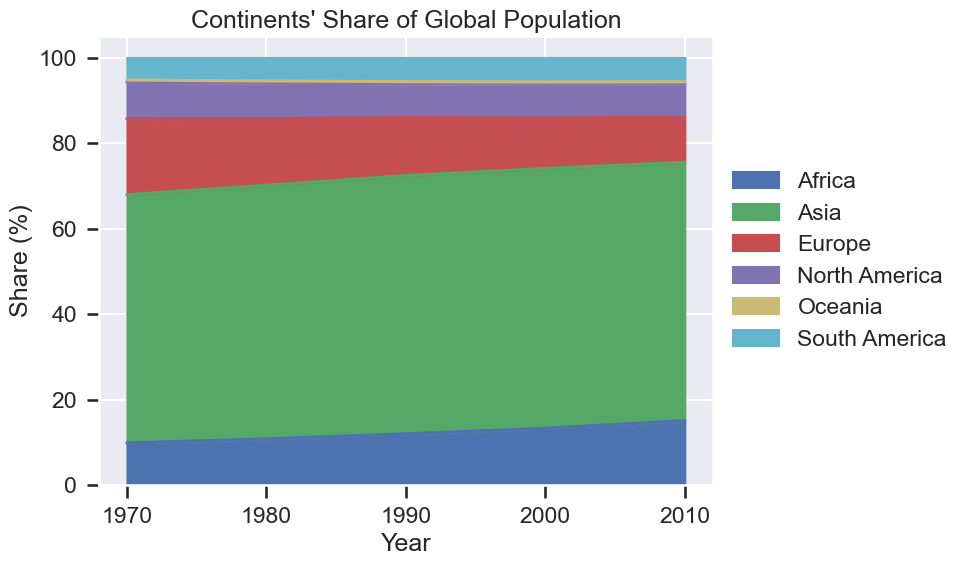

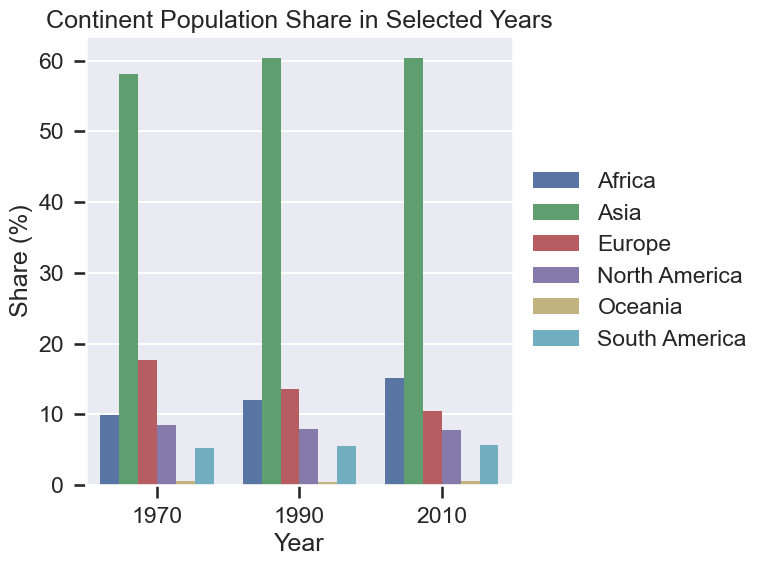

In [5]:
#6 - Which continent's share in global population has shrunk over the years, and which has grown?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
pop_continent = pd.read_csv("world_population_withContinent.csv")

# Reshape (melt) to long format
pop_long = pop_continent.melt(
    id_vars=["Continent"], 
    value_vars=["1970 Population","1980 Population","1990 Population","2000 Population","2010 Population"],
    var_name="Year",
    value_name="Population"
)

# Clean Year column
pop_long["Year"] = pop_long["Year"].str.replace(" Population","").astype(int)

# Compute share
continent_share = pop_long.groupby(["Year","Continent"])["Population"].sum().reset_index()
total_per_year = continent_share.groupby("Year")["Population"].transform("sum")
continent_share["Share"] = (continent_share["Population"]/total_per_year)*100

# Pivot for stacked area
pivot_share = continent_share.pivot(index="Year", columns="Continent", values="Share")

# Plot stacked area chart with legend outside
ax1 = pivot_share.plot(kind="area", stacked=True, figsize=(10,6))
plt.title("Continents' Share of Global Population")
plt.ylabel("Share (%)")
plt.xlabel("Year")
ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Bar chart for selected years with legend outside
sample_years = continent_share[continent_share["Year"].isin([1970,1990,2010])]

plt.figure(figsize=(8,6))
ax2 = sns.barplot(data=sample_years, x="Year", y="Share", hue="Continent")
plt.title("Continent Population Share in Selected Years")
plt.ylabel("Share (%)")
ax2.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()


/tmp/ipykernel_14328/2831900978.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lit_subset, x='Country', y='Female', palette='Set2')


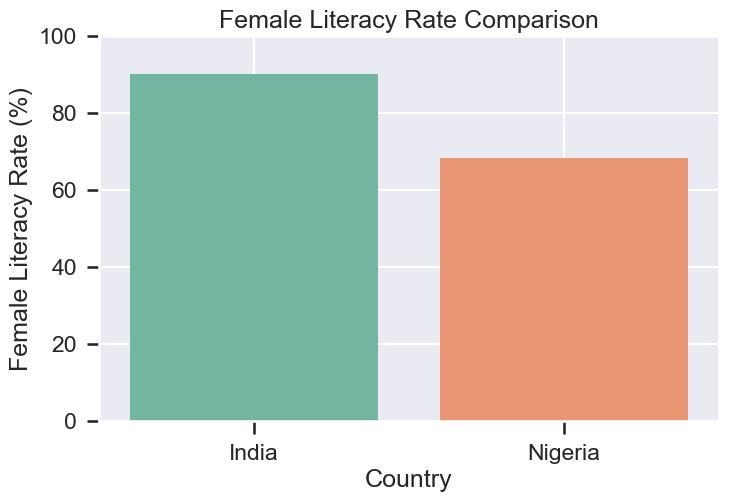

/tmp/ipykernel_14328/2831900978.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pop_growth, x='Country', y='Population Growth (%)', palette='Set1')


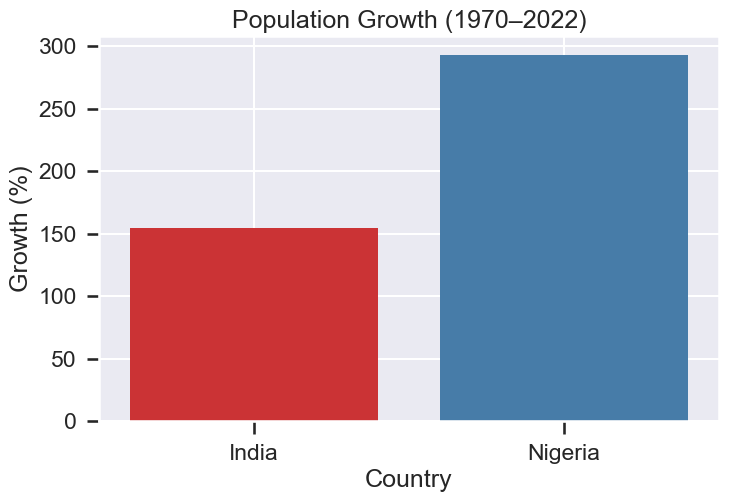

In [7]:
#7-How does female literacy influence population growth? Compare India and Nigeria
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# Load datasets
lit_df = pd.read_excel('regional-agg_LiteracyRate.xlsx', header=1)
pop_df = pd.read_csv('world_population_withContinent.csv')

# Clean column names
lit_df.columns = lit_df.columns.str.strip()
pop_df.columns = pop_df.columns.str.strip()

# Standardize country names
lit_df['Country'] = lit_df['Country'].str.strip()
pop_df['Country/Territory'] = pop_df['Country/Territory'].str.strip()

# Select countries
countries = ['India', 'Nigeria']

# Extract female literacy
lit_subset = lit_df[lit_df['Country'].isin(countries)][['Country', 'Female']].dropna()

# Calculate population growth
pop_subset = pop_df[pop_df['Country/Territory'].isin(countries)].copy()
pop_subset.rename(columns={'Country/Territory': 'Country'}, inplace=True)
pop_subset['Population Growth (%)'] = ((pop_subset['2022 Population'] - pop_subset['1970 Population']) / pop_subset['1970 Population']) * 100
pop_growth = pop_subset[['Country', 'Population Growth (%)']]

# --- Plot 1: Female Literacy ---
plt.figure(figsize=(8,5))
sns.barplot(data=lit_subset, x='Country', y='Female', palette='Set2')
plt.title('Female Literacy Rate Comparison')
plt.ylabel('Female Literacy Rate (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

# --- Plot 2: Population Growth ---
plt.figure(figsize=(8,5))
sns.barplot(data=pop_growth, x='Country', y='Population Growth (%)', palette='Set1')
plt.title('Population Growth (1970–2022)')
plt.ylabel('Growth (%)')
plt.grid(True)
plt.show()


/tmp/ipykernel_14328/637468215.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gdp_compare, x='Country', y='GDP (Billion USD)', palette='coolwarm')


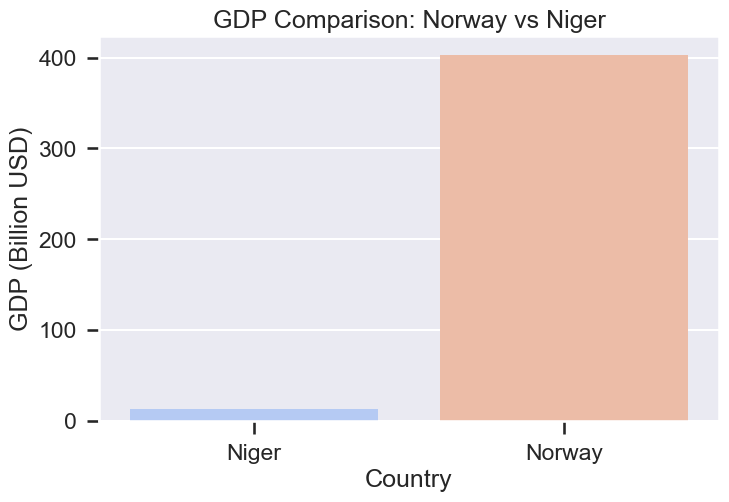

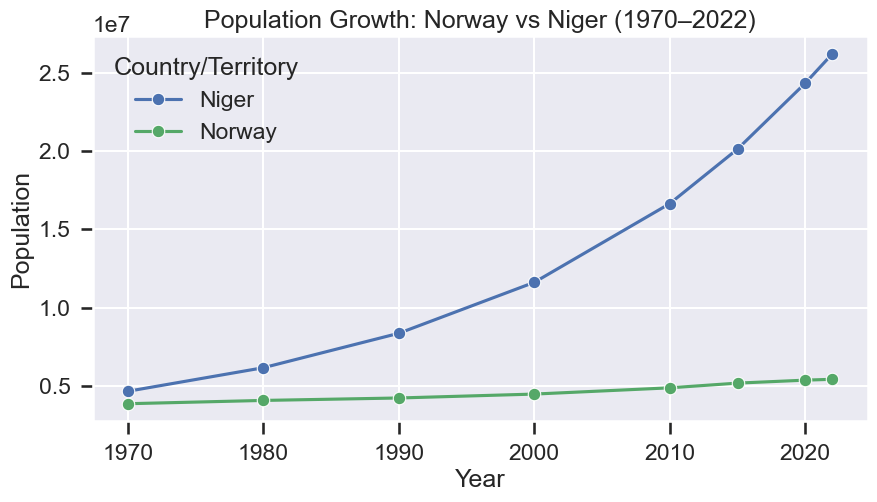

In [9]:
#8 - How does GDP per capita influence population growth when comparing high-income countries like Norway with
#low-income countries like Niger?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# Load datasets
gdp_df = pd.read_csv('world-data-2023.csv')
pop_df = pd.read_csv('world_population_withContinent.csv')

# Clean column names
gdp_df.columns = gdp_df.columns.str.strip()
pop_df.columns = pop_df.columns.str.strip()

# Standardize country names
gdp_df['Country'] = gdp_df['Country'].str.strip()
pop_df['Country/Territory'] = pop_df['Country/Territory'].str.strip()

# Clean and convert GDP to numeric
gdp_df['GDP'] = gdp_df['GDP'].replace(r'[\$,]', '', regex=True)
gdp_df['GDP'] = pd.to_numeric(gdp_df['GDP'], errors='coerce')
gdp_df = gdp_df.dropna(subset=['GDP'])
gdp_df['GDP (Billion USD)'] = gdp_df['GDP'] / 1e9

# Select countries
countries = ['Norway', 'Niger']
gdp_compare = gdp_df[gdp_df['Country'].isin(countries)]

# Plot 1: GDP Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=gdp_compare, x='Country', y='GDP (Billion USD)', palette='coolwarm')
plt.title('GDP Comparison: Norway vs Niger')
plt.ylabel('GDP (Billion USD)')
plt.show()

# Population growth comparison
pop_compare = pop_df[pop_df['Country/Territory'].isin(countries)].copy()
pop_compare = pop_compare.melt(id_vars=['Country/Territory'], var_name='Year', value_name='Population')
pop_compare['Year'] = pop_compare['Year'].str.extract(r'(\d{4})')
pop_compare = pop_compare.dropna(subset=['Year'])
pop_compare['Year'] = pop_compare['Year'].astype(int)

# Plot 2: Population Growth Over Time
plt.figure(figsize=(10,5))
sns.lineplot(data=pop_compare, x='Year', y='Population', hue='Country/Territory', marker='o')
plt.title('Population Growth: Norway vs Niger (1970–2022)')
plt.ylabel('Population')
plt.show()


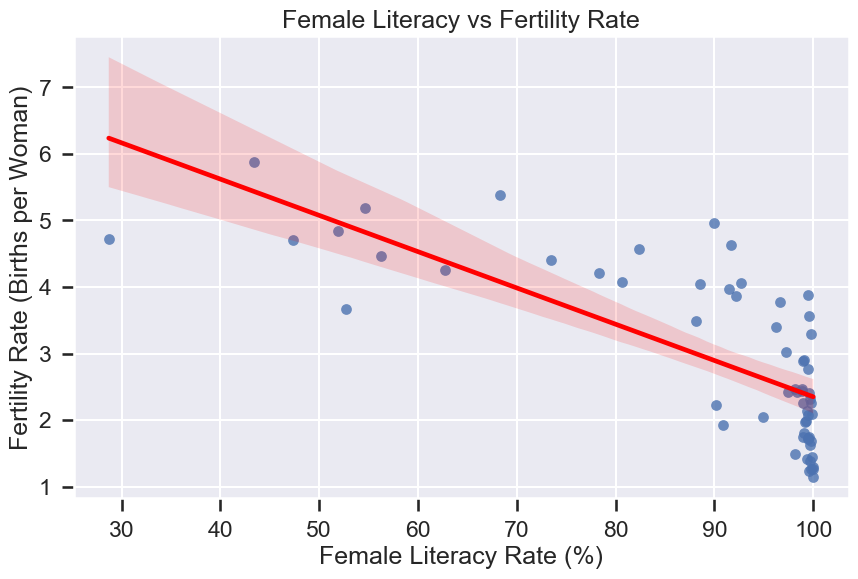

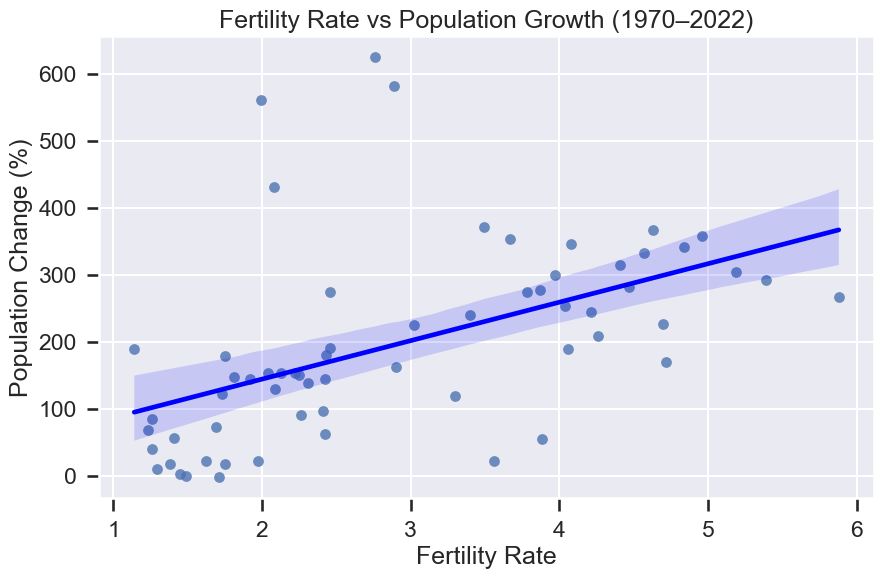

In [ ]:
#9-How does female literacy influence fertility rate, and thereby affect population growth across countries?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# Load datasets
lit_df = pd.read_excel('regional-agg_LiteracyRate.xlsx', header=1)
world_df = pd.read_csv('world-data-2023.csv')
pop_df = pd.read_csv('world_population_withContinent.csv')

# Clean column names
lit_df.columns = lit_df.columns.str.strip()
world_df.columns = world_df.columns.str.strip()
pop_df.columns = pop_df.columns.str.strip()

# Standardize country names
lit_df['Country'] = lit_df['Country'].str.strip()
world_df['Country'] = world_df['Country'].str.strip()
pop_df['Country/Territory'] = pop_df['Country/Territory'].str.strip()

# Prepare population change
pop_change = pop_df[['Country/Territory', '1970 Population', '2022 Population']].copy()
pop_change.rename(columns={'Country/Territory': 'Country', '1970 Population': 'Pop_1970', '2022 Population': 'Pop_2022'}, inplace=True)
pop_change['Population Change (%)'] = ((pop_change['Pop_2022'] - pop_change['Pop_1970']) / pop_change['Pop_1970']) * 100

# Merge literacy, fertility, and population change
lit_subset = lit_df[['Country', 'Female']].dropna()
fert_subset = world_df[['Country', 'Fertility Rate']].dropna()
merged = pd.merge(lit_subset, fert_subset, on='Country', how='inner')
merged = pd.merge(merged, pop_change[['Country', 'Population Change (%)']], on='Country', how='inner')

# Plot: Female Literacy vs Fertility Rate
plt.figure(figsize=(10,6))
sns.regplot(data=merged, x='Female', y='Fertility Rate', scatter_kws={'s': 60}, line_kws={'color': 'red'})
plt.title('Female Literacy vs Fertility Rate')
plt.xlabel('Female Literacy Rate (%)')
plt.ylabel('Fertility Rate (Births per Woman)')
plt.grid(True)
plt.show()

# Plot: Fertility Rate vs Population Change
plt.figure(figsize=(10,6))
sns.regplot(data=merged, x='Fertility Rate', y='Population Change (%)', scatter_kws={'s': 60}, line_kws={'color': 'blue'})
plt.title('Fertility Rate vs Population Growth (1970–2022)')
plt.xlabel('Fertility Rate')
plt.ylabel('Population Change (%)')
plt.grid(True)
plt.show()


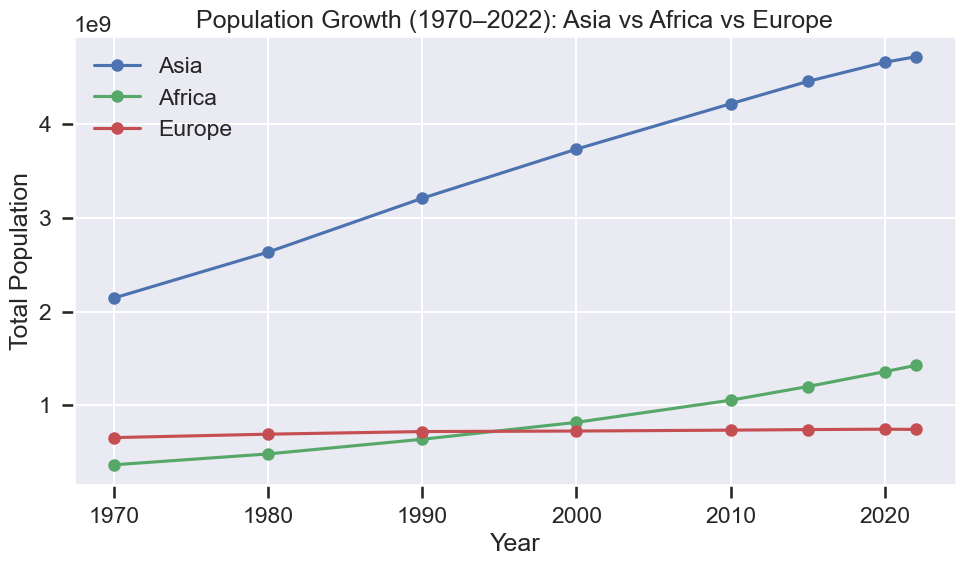

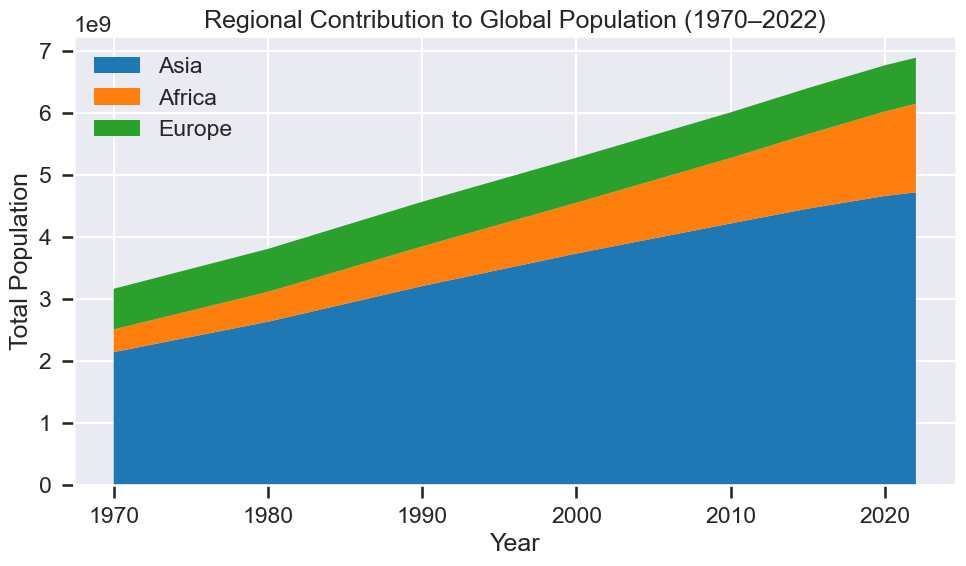

In [ ]:
#10 - How has the global population growth curve changed visually across different regions — Asia, Africa, Europe?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# Load dataset
df = pd.read_csv('world_population_withContinent.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Filter for Asia, Africa, Europe
regions = ['Asia', 'Africa', 'Europe']
df = df[df['Continent'].isin(regions)]

# Extract year columns (1970–2022)
year_cols = [col for col in df.columns if 'Population' in col and col[:4].isdigit()]
df_years = df[['Continent'] + year_cols]

# Group by continent and sum population per year
grouped = df_years.groupby('Continent').sum().transpose()
grouped.index = grouped.index.str.extract(r'(\d{4})')[0].astype(int)

# --- Plot 1: Line Chart ---
plt.figure(figsize=(10,6))
for region in regions:
    plt.plot(grouped.index, grouped[region], label=region, marker='o')

plt.title('Population Growth (1970–2022): Asia vs Africa vs Europe')
plt.xlabel('Year')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Stacked Area Chart ---
plt.figure(figsize=(10,6))
plt.stackplot(grouped.index, grouped['Asia'], grouped['Africa'], grouped['Europe'],
              labels=regions, colors=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Regional Contribution to Global Population (1970–2022)')
plt.xlabel('Year')
plt.ylabel('Total Population')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
